In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
import ast
import math
import matplotlib.patches as patches

from sklearn.metrics import f1_score, confusion_matrix, accuracy_score

PATH_ACTIONS    = "../../Data/Processed/actions_filtered.csv"
PATH_KEYPOINTS  = "../../Data/Unprocessed/keypoints.csv"
PATH_CLIPS      = "../../Data/Videos/Clips/"

PATH_TEST       = "../../../Experiments/Base/test.csv"

EDGES = [
    (0, 1), (1, 3),
    (3, 5), (1, 2),
    (0, 2), (2, 4),
    (4, 6),
    (5, 7), (7, 9),     # left arm
    (6, 8), (8, 10),    # right arm
    (5, 6),             # shoulders
    (11, 12),           # hips
    (5, 11), (6, 12),   # torso
    (11, 13), (13, 15), # left leg
    (12, 14), (14, 16)  # right leg
]

In [40]:
def draw_frame(df, video_file, frame_idx):
    df = df[(df["file"] == video_file) & (df["frame"] == frame_idx)]
    if df.empty:
        print(f"No data found for frame {frame_idx} in {video_file}")
        return

    video_path = PATH_CLIPS + video_file
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Cannot open video {video_file}")
        return

    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame = cap.read()
    if not ret:
        print(f"Could not read frame {frame_idx}")
        cap.release()
        return

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(frame_rgb)
    ax.axis("off")

    row = df.iloc[0]

    # ---- ROI ----
    if "roi" in df.columns and row["roi"] is not None:
        x1, y1, x2, y2 = row["roi"]
        rect = patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2,
            edgecolor="yellow",
            facecolor="none"
        )
        #ax.add_patch(rect)

    # ---- Draw fencers ----
    for side, color, x_text in [
        ("LEFT", (1, 0, 0), 25),
        ("RIGHT", (0, 1, 0), 1250),
    ]:
        kp_col = f"{side.lower()}_keypoints"
        flag = False

        if kp_col in df.columns:
            keypoints = row[kp_col]
            if keypoints and len(keypoints) > 0:
                plot_skeleton_ax(ax, keypoints, color=color)
                flag = True

    ax.set_title(f"{video_file} — Frame {frame_idx}")

    plt.tight_layout()
    plt.show()
    cap.release()

def plot_skeleton_ax(ax, keypoints, color=(0,1,0), alpha=0.8):
    keypoints = np.array(keypoints)
    for (i,j) in EDGES:
        if i >= len(keypoints) or j >= len(keypoints):
            continue
        x1, y1 = keypoints[i]
        x2, y2 = keypoints[j]
        ax.plot([x1,x2],[y1,y2], color=color, alpha=alpha, linewidth=2)
    ax.scatter(keypoints[:,0], keypoints[:,1], color=color, s=20)


In [2]:
def draw_file(df, video_file, cols=2):
    df = df[df["file"] == video_file]
    frame_indices = sorted(df['frame'].unique())
    n_frames = len(frame_indices)
    rows = math.ceil(n_frames / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(8 * cols, 6 * rows))
    axes = axes.flatten()

    video_path = PATH_CLIPS + video_file
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Cannot open video {video_file}")
        return

    # Column mapping (edit here if names change)
    label_cols = {
        "LEFT": ("left_label_gt", "left_label_pred"),
        "RIGHT": ("right_label_gt", "right_label_pred"),
    }

    for i, frame_idx in enumerate(frame_indices):
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ret, frame = cap.read()
        if not ret:
            continue

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        ax = axes[i]
        ax.imshow(frame_rgb)
        ax.axis("off")

        row = df[df['frame'] == frame_idx]
        if row.empty:
            continue

        # ---- Draw ROI ----
        roi = row['roi'].values[0] if 'roi' in row else None
        if roi is not None:
            x1, y1, x2, y2 = roi
            rect = patches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                linewidth=2, edgecolor="yellow", facecolor="none"
            )
            ax.add_patch(rect)

        # ---- Draw fencers ----
        for side, color, x_text in [
            ("LEFT", (1, 0, 0), 25),
            ("RIGHT", (0, 1, 0), 1250),
        ]:
            kp_col = f"{side.lower()}_keypoints"
            if kp_col in row:
                keypoints = row[kp_col].values[0]
                flag = keypoints and len(keypoints) > 0
                if flag:
                    plot_skeleton_ax(ax, keypoints, color=color)

            # ---- Labels ----
            gt_col, pred_col = label_cols[side]
            gt = row[gt_col].values[0]
            pred = row[pred_col].values[0] if flag else "Missing Keypoints"

            label_str = [
                f"Real: {gt}",
                f"Pred: {pred}",
            ]

            if label_str:
                ax.text(
                    x_text, 130,
                    f"{side}\n" + "\n".join(label_str),
                    color=color,
                    fontsize=10,
                    weight="bold",
                    bbox=dict(facecolor="black", alpha=0.5, pad=3),
                )

            ax.set_title(f"Frame {frame_idx}")

    # Hide unused subplots
    for j in range(n_frames, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()
    cap.release()

def plot_skeleton_ax(ax, keypoints, color=(0,1,0), alpha=0.8):
    keypoints = np.array(keypoints)
    for (i,j) in EDGES:
        if i >= len(keypoints) or j >= len(keypoints):
            continue
        x1, y1 = keypoints[i]
        x2, y2 = keypoints[j]
        ax.plot([x1,x2],[y1,y2], color=color, alpha=alpha, linewidth=2)
    ax.scatter(keypoints[:,0], keypoints[:,1], color=color, s=20)


In [3]:
def draw_action(df, action_id, cols=3):
    df = df[df["action_id"] == action_id]
    file = df["file"].unique()[0]

    frame_indices = sorted(df['frame'].unique())
    n_frames = len(frame_indices)
    rows = math.ceil(n_frames / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(8 * cols, 6 * rows))
    axes = axes.flatten()

    video_path = PATH_CLIPS + file
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Cannot open video {file}")
        return

    for i, frame_idx in enumerate(frame_indices):
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ret, frame = cap.read()
        if not ret:
            continue

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        ax = axes[i]
        ax.imshow(frame_rgb)
        ax.axis("off")

        row = df[df['frame'] == frame_idx]
        if row.empty:
            continue

        # ---- Draw ROI ----
        roi = row['roi'].values[0] if 'roi' in row else None
        if roi is not None:
            x1, y1, x2, y2 = roi
            rect = patches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                linewidth=2, edgecolor="yellow", facecolor="none"
            )
            ax.add_patch(rect)

        row = df[(df['frame'] == frame_idx)]
        fencer = row['fencer'].values[0] 
        keypoints = row['keypoints'].values[0] 
        if keypoints and not (isinstance(keypoints, float) and np.isnan(keypoints)): 
            plot_skeleton_ax(ax, keypoints, color=(1,0,0) if fencer == 'LEFT' else (0,1,0))

        ax.set_title(f"Frame {frame_idx}")

    # Hide unused subplots
    for j in range(n_frames, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()
    cap.release()

def plot_skeleton_ax(ax, keypoints, color=(0,1,0), alpha=0.8):
    keypoints = np.array(keypoints)
    for (i,j) in EDGES:
        if i >= len(keypoints) or j >= len(keypoints):
            continue
        x1, y1 = keypoints[i]
        x2, y2 = keypoints[j]
        ax.plot([x1,x2],[y1,y2], color=color, alpha=alpha, linewidth=2)
    ax.scatter(keypoints[:,0], keypoints[:,1], color=color, s=20)


In [83]:
df_test = pd.read_csv(PATH_TEST)

df_test["roi"] = df_test["roi"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

df_test["left_keypoints"] = df_test["left_keypoints"].apply(
    lambda x: [tuple(p) for p in ast.literal_eval(x)] if isinstance(x, str) else x
)

df_test["right_keypoints"] = df_test["right_keypoints"].apply(
    lambda x: [tuple(p) for p in ast.literal_eval(x)] if isinstance(x, str) else x
)

df_test.head()

,file,frame,left_label_gt,left_label_pred,right_label_gt,right_label_pred,roi,left_keypoints,right_keypoints
0,3/10_Left.mp4,0,NO_ACTION,NO_ACTION,NO_ACTION,NO_ACTION,"[0, 613, 1920, 888]","[(666.6803588867188, 606.3458862304688), (664....","[(1332.2054443359375, 622.6754150390625), (133..."
1,3/10_Left.mp4,1,NO_ACTION,NO_ACTION,NO_ACTION,NO_ACTION,"[0, 613, 1920, 888]","[(671.4364013671875, 605.85546875), (668.23175...","[(1332.0628662109375, 623.4649658203125), (133..."
2,3/10_Left.mp4,2,NO_ACTION,NO_ACTION,NO_ACTION,NO_ACTION,"[0, 613, 1920, 888]","[(672.5331420898438, 609.384033203125), (670.2...","[(1327.909423828125, 623.5018920898438), (1332..."
3,3/10_Left.mp4,3,NO_ACTION,NO_ACTION,NO_ACTION,NO_ACTION,"[0, 613, 1920, 888]","[(677.8299560546875, 605.5946044921875), (676....","[(1327.14306640625, 624.1072998046875), (1332...."
4,3/10_Left.mp4,4,NO_ACTION,NO_ACTION,NO_ACTION,NO_ACTION,"[0, 613, 1920, 888]","[(681.3656005859375, 603.2425537109375), (678....","[(1325.217529296875, 623.9931030273438), (1330..."


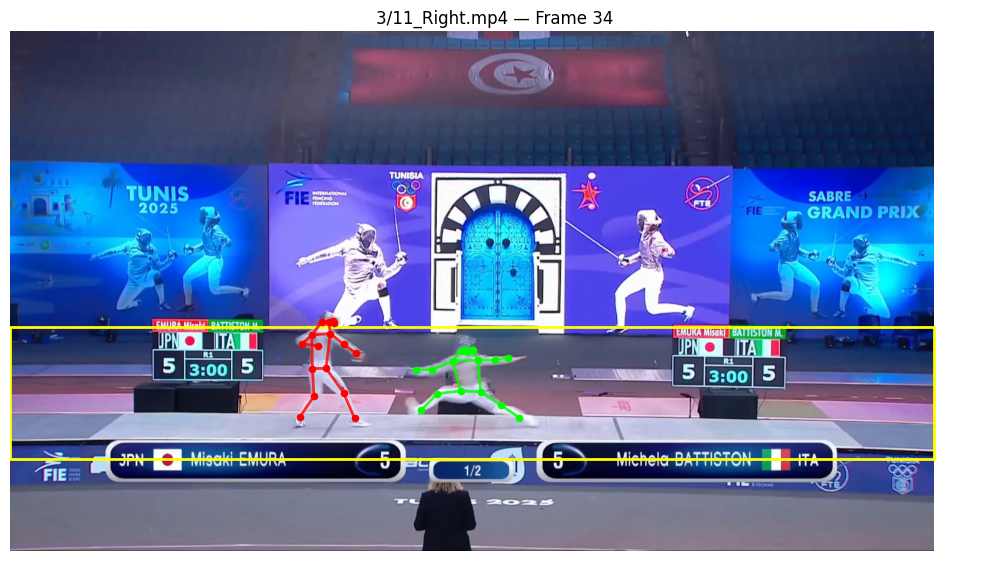

In [18]:
files = df_test["file"].unique()
draw_frame(df_test, files[1], 34)

In [35]:
df_keypoints = pd.read_csv(PATH_KEYPOINTS)
df_actions = pd.read_csv(PATH_ACTIONS)

df_keypoints["keypoints"] = df_keypoints["keypoints"].apply(
    lambda x: [tuple(p) for p in ast.literal_eval(x)] if isinstance(x, str) else x
)

df_keypoints["roi"] = df_keypoints["roi"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

df_merged = df_keypoints.merge(df_actions, on=["file", "fencer"], how="left")
df_merged = df_merged[
    (df_merged["frame"] >= df_merged["start_frame"]) &
    (df_merged["frame"] <= df_merged["end_frame"])
]

df_merged = df_merged[["file", "fencer", "action_id", "action", "frame", "start_frame", "end_frame", "confidence", "roi", "keypoints"]].reset_index(drop=True)

df_merged.head()

,file,fencer,action_id,action,frame,start_frame,end_frame,confidence,roi,keypoints
0,1/10_Left.mp4,LEFT,0,NO_ACTION,0,0,22,0.898973,"[0, 590, 1920, 836]","[(651.2871704101562, 605.3470458984375), (654...."
1,1/10_Left.mp4,LEFT,0,NO_ACTION,1,0,22,0.885350,"[0, 590, 1920, 836]","[(652.6170654296875, 606.501953125), (655.7320..."
2,1/10_Left.mp4,LEFT,0,NO_ACTION,2,0,22,0.867700,"[0, 590, 1920, 836]","[(654.3292236328125, 608.1226806640625), (657...."
3,1/10_Left.mp4,LEFT,0,NO_ACTION,3,0,22,0.881394,"[0, 590, 1920, 836]","[(658.3043823242188, 607.803466796875), (661.1..."
4,1/10_Left.mp4,LEFT,0,NO_ACTION,4,0,22,0.856014,"[0, 590, 1920, 836]","[(664.1746826171875, 605.3037719726562), (665...."


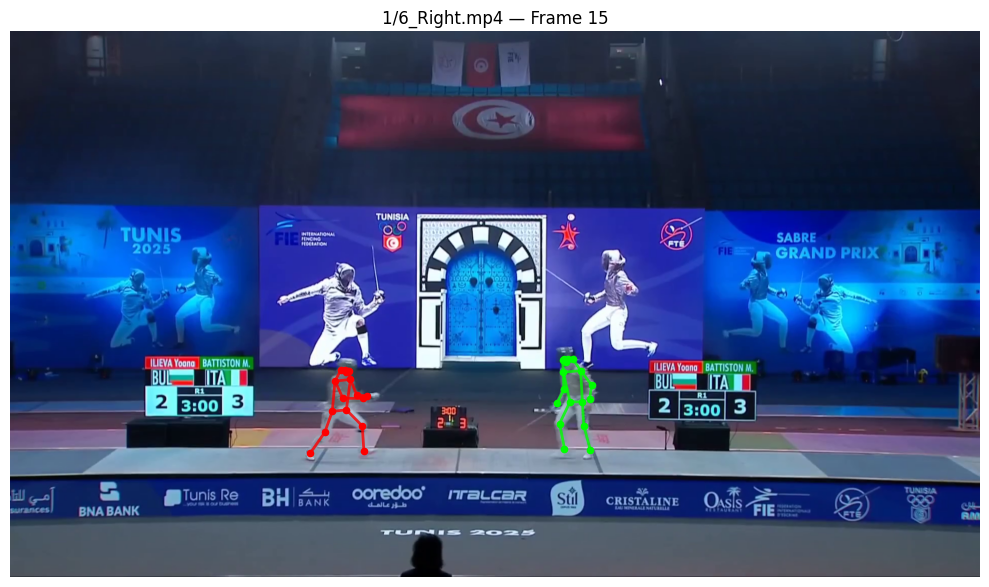

In [78]:
df_merged["bout"] = df_merged["file"].str.split("/").str[0]
grouped = df_merged[df_merged["bout"] == "1"]

grouped_left = grouped[grouped["fencer"] == "LEFT"].copy()
grouped_right = grouped[grouped["fencer"] == "RIGHT"].copy()

grouped_left.rename(columns={"keypoints": "left_keypoints", "action": "left_action"}, inplace=True)
grouped_right.rename(columns={"keypoints": "right_keypoints", "action": "right_action"}, inplace=True)

grouped_left.drop(columns=["fencer"], inplace=True)
grouped_right.drop(columns=["fencer"], inplace=True)

grouped = grouped_left.merge(grouped_right, on=["file", "frame"], how="left")
draw_frame(grouped, grouped["file"].unique()[20], 15)

In [ ]:
sample = df_merged.sample(50)

for action_id in sample["action_id"].unique():
    file = df_merged[df_merged["action_id"] == action_id]["file"].unique()[0]

    print(f"Action {action_id} in file {file}")
    draw_action(df_merged, action_id=action_id, cols=4)

In [23]:
def action_count_histogram(df):
    action_counts = df["action"].value_counts()
    plt.bar(action_counts.index, action_counts.values)
    plt.xlabel("Action")
    plt.ylabel("Count")
    plt.title("Action Count Histogram")
    plt.xticks(rotation=45)
    plt.show()

action
NO_ACTION       593
LONG_ATTACK     235
SHORT_ATTACK    181
DIST_PULL        92
PARRY            26
Name: count, dtype: int64


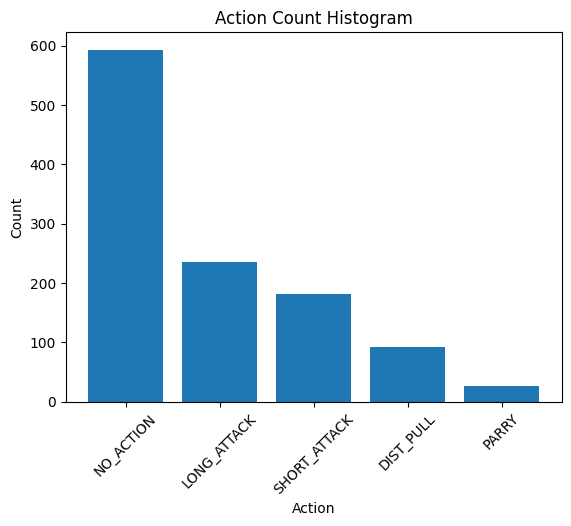

In [24]:
df_actions = pd.read_csv(PATH_ACTIONS)
action_counts = df_actions["action"].value_counts()
print(action_counts)

action_count_histogram(df_actions)

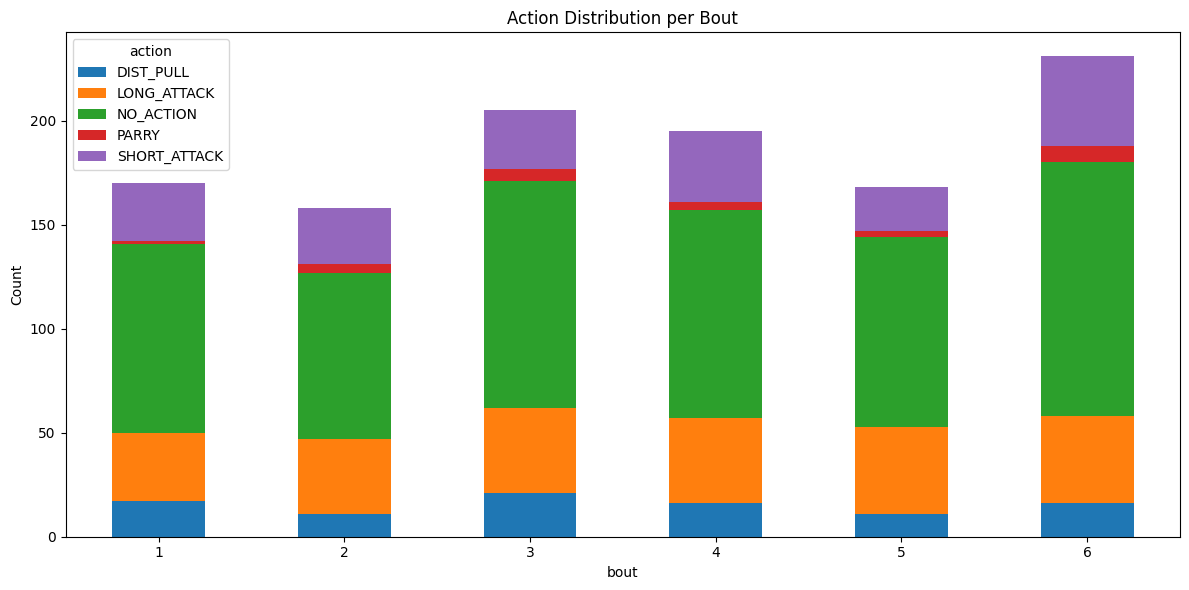

In [34]:
counts = (
    df_actions
    .groupby("bout")["action"]
    .value_counts()
    .unstack(fill_value=0)
)

counts.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.ylabel("Count")
plt.title("Action Distribution per Bout")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [85]:
y_true = np.concatenate([
    df_test["left_label_gt"].values,
    df_test["right_label_gt"].values
])

y_pred = np.concatenate([
    df_test["left_label_pred"].values,
    df_test["right_label_pred"].values
])

In [86]:
macro_f1 = f1_score(y_true, y_pred, average="macro")
weighted_f1 = f1_score(y_true, y_pred, average="weighted")

print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)

Macro F1: 0.6922839017257487
Weighted F1: 0.882203813227667


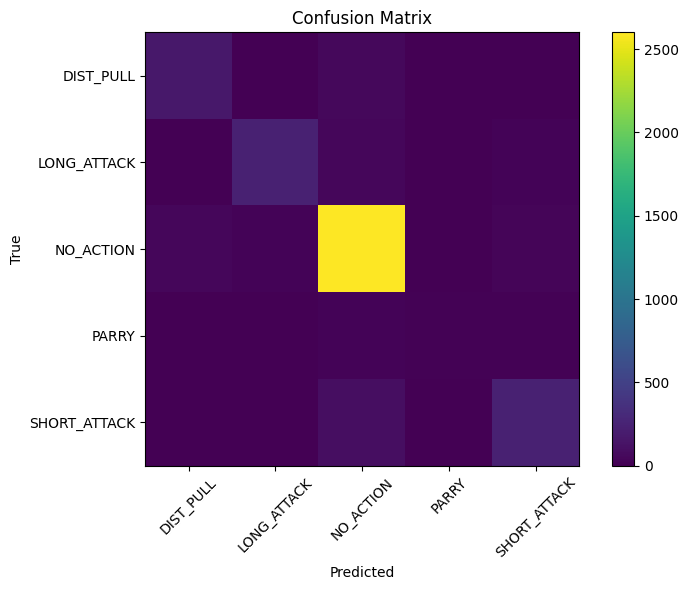

In [88]:
labels = sorted(np.unique(y_true))
cm = confusion_matrix(y_true, y_pred, labels=labels)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation="nearest")
plt.colorbar()

plt.xticks(range(len(labels)), labels, rotation=45)
plt.yticks(range(len(labels)), labels)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

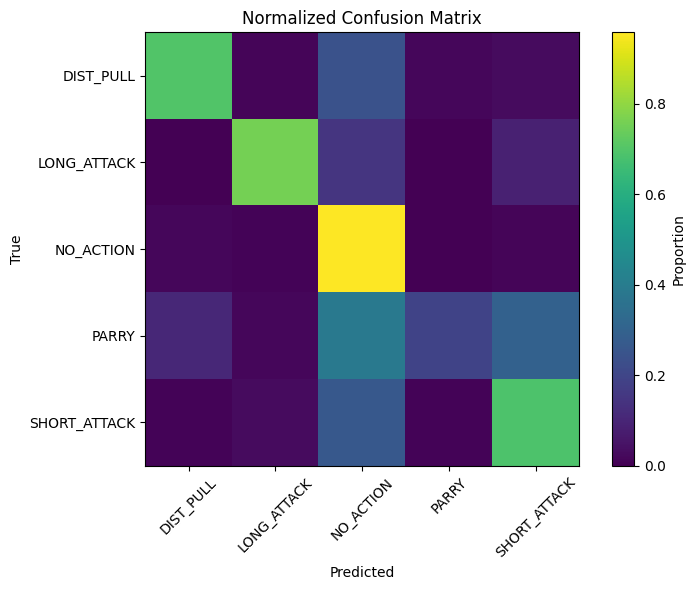

In [89]:
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(8, 6))
plt.imshow(cm_norm)
plt.colorbar(label="Proportion")

plt.xticks(range(len(labels)), labels, rotation=45)
plt.yticks(range(len(labels)), labels)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized Confusion Matrix")

plt.tight_layout()
plt.show()

In [93]:
baseline = df_test.copy()

baseline["left_label_pred"] = "NO_ACTION"
baseline["right_label_pred"] = "NO_ACTION"

y_true = np.concatenate([
    df_test["left_label_gt"].values,
    df_test["right_label_gt"].values
])

y_pred = np.concatenate([
    baseline["left_label_pred"].values,
    baseline["right_label_pred"].values
])

macro_f1 = f1_score(y_true, y_pred, average="macro")
weighted_f1 = f1_score(y_true, y_pred, average="weighted")

print(len(y_true))
print(len(y_pred))

accuracy = accuracy_score(y_true, y_pred)
print("Accuracy:", accuracy)

print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)

3670
3670
Accuracy: 0.7395095367847412
Macro F1: 0.1700501253132832
Weighted F1: 0.6287684470030663
